<a href="https://colab.research.google.com/github/VarzarMiruna/JAVA2024/blob/main/tema1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV2026 (CAVA) - Week 1

> Varzar Alina-Miruna

> MISS1



# **Exercițiul 1**

Pentru numărul de flops per pixel am avut în codul de la laborator calculul pentru o imagine grayscale.

Am pornit de la faptul că funcția cumsum_prod() returnează $np.sum(a*b)$.

Pentru un filtru de dimensiune n, unde n este KxK funcția cumsum_prod calculează $a*b$ (înmulțirea element cu element), făcând $K^2$ înmulțiri. Apoi adună aceste $K^2$ produse. Astfel pentru a aduna n numere sunt necesare n-1 operații, deci avem $K^2 - 1$ adunări.

Rezultă că pentru un singur pixel de pe un singur canal am obținut:
$$K^2 + (K^2 - 1) = 2K^2 - 1$$

În funcția generic convolution din demo se folosesc două bucle for pentru a glisa filtrul peste întreaga imagine. Un for pe înălțimea h și încă unul pentru lățimea w. Astfel pentru imaginea alb-negru folosită în demo, totalul ar fi de  

$$h \cdot w \cdot (2K^2 - 1)$$ flops.  

Astfel pentru o  imagine color cu 3 canale volumul total de operații se triplează. Deoarece filtrarea clasică presupune aplicarea aceluiași filtru  K×K  independent pe fiecare canal de culoare în parte.
$$3 \cdot h \cdot w \cdot (2K^2 - 1)$$



# **Exercițiul 2**

Pentru a rezolva exercițiul 2 am urmărit un tutorial care m-a ajutat să instalez CPU-z și astfel să aflu detalii despre suportul laptopului meu. Am atașat și o imagine din aplicație.

Model CPU: AMD Ryzen 7 7735HS.

Procesorul oferă suport FMA și implementează AVX. De exemplu cu ajutorul acestora calculele matriciale sunt mult mai rapide.


**Imaginea din aplicație:**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


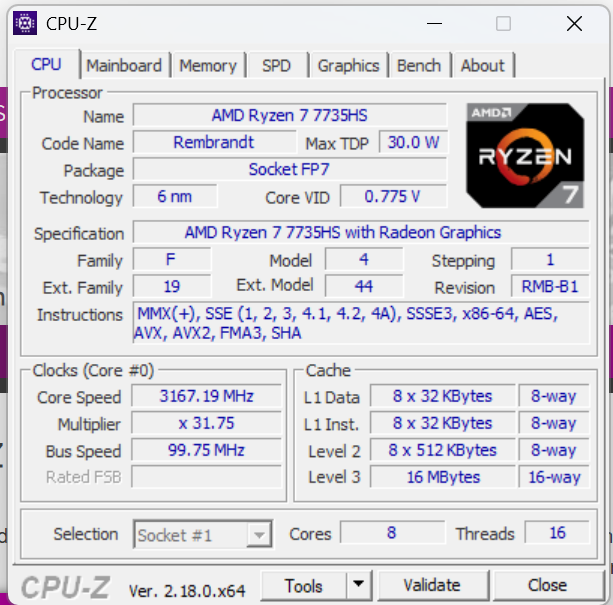

In [8]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/CAVA_2026/teaching/week1/imgs_miru/Screenshot 2026-02-23 141052.png", width=400))

După ce am comparat cu formula de la exercițiul 1 rezultă că un sistem cu 4xFMA ALU ar aduce un speed-up teoretic de $8x$.

Deoarece la exercițiul 1 este nevoie de o operație de înmulțire și una de adunare pentru fiecare element. FMA combină aceste două operații distincte într-un singur ciclu ($a * b + c$). Acest lucru oferă o accelerare de $2x$.

Opțiunea 4xFMA ALU înseamnă că procesorul poate executa 4 instrucțiuni FMA paralele, în același timp. Se folosește de registrele vectoriale AVX confirmate mai sus. Asta oferă o accelerare de $4x$.

Astfel înmulțind factorul 2 de la FMA cu factorul 4 din execuția paralelă, rezultă o procesare de 8 ori mai rapidă față de calculul de la exercițiul 1.

# **Exercițiul 3**

În exemplul de la laborator pentru filtrul median se sortează toate elementele cu np.sort(). La filtrul median se urmărește exclusiv obținerea medianei, adică a unui singur element, a celui din mijloc.

În demo am observat la secțiunea 12 următorul cod:

```
def get_median(a, b=None):
  h, w  = a.shape
  a_flat = a.flatten()
  a_sorted = np.sort(a_flat)
  return a_sorted[h * w // 2]
```

Pentru a implementa filtrul median de dimensiune $K \times K$, am notat numărul total de elemente din fereastră cu $n$, unde $n = K^2$. Iar pentru a optimiza filtrul median, am analizat și am comparat complexitatea timp a următorilor algoritmi de sortare, luând în calcul faptul că valorile pixelilor sunt între 0 și 255.

**Algoritmi de sortare simplă Bubble, Selection, Insertion Sort**

Au complexitatea timp $O(n^2)$.

Sunt în general ineficienți și prea lenți pentru procesarea de imagini pe rezoluții mari.

**Algoritmii Merge, Quick, Heap Sort**

Au complexitatea timp $O(n \log n)$.

Sortează restul elementelor din fereastră, pe lângă mediană.

**Algoritmul de Selecție Quickselect**

Are complexitatea timp $O(n)$ în cazul mediu.


**Counting Sort (Sortarea pe Histogramă)**

Are complexitatea timp $O(n)$.

Deoarece se cunoaște că pixelii pot lua doar 256 de valori discrete ($0–255$), comparațiile între elemente pot fi eliminate complet.

Astfel pentru implementarea unui filtru median rapid se poate folosi un algoritm de $O(n)$, cum ar fi Counting Sort (bazat pe histogramă). Deoarece valorile posibile ale pixelilor sunt limitate, algoritmul transformă sortarea într-o simplă numărare liniară.

Asta reduce complexitatea per pixel  de la $O(n)$ la $O(K)$.

# **Exercițiul 4**

**Avantaj al filtrului median:**

**Păstrarea marginilor și eliminarea zgomotului**

Filtrul mediu (average filter) ia toți pixelii dintr-o vecinătate și face media lor aritmetică. Dacă în acea zonă există un pixel cu zgomot extrem (de exemplu un pixel complet negru sau complet alb, specific zgomotului salt and pepper), acea valoare extremă va trage media în jos sau în sus, creând o pată gri (blur). În schimb, filtrul median sortează pixelii și alege strict valoarea din mijloc. Astfel, valorile extreme (zgomotul) sunt ignorate total, fiind aruncate la capetele listei sortate. Rezultatul este că zgomotul este eliminat complet, iar marginile obiectelor rămân clare, nefiind blurate.


**Dezavantaj al Filtrului Median:**

**Eficiență redusă**

Filtrul mediu este o operație liniară simplă (o convoluție clasică). Presupune doar adunări și o singură înmulțire/împărțire pe o fereastră de calcul, operații extrem de optimizate la nivel hardware (cum am arătat mai sus la exercițiile 1 și 2).

În schimb filtrul median este o operație neliniară care necesită sortarea (sau cel puțin partiționarea) tuturor pixelilor din fereastră la fiecare pas (așa cum am detaliat la Exercițiul 3). Acest proces de sortare este mult mai lent din punct de vedere algoritmic, făcând filtrul median mai greu de rulat în timp real pe imagini de înaltă rezoluție, comparativ cu filtrul average.

# **Exercițiul 5**
 Implementarea:


In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bender_img = cv.imread("/content/drive/MyDrive/CAVA_2026/teaching/week1/imgs/bender.png")
bender_img_gray = cv.cvtColor(bender_img, cv.COLOR_BGR2GRAY)

h, w = bender_img_gray.shape

#transformata Fourier rapidă
f_transform = np.fft.fft2(bender_img_gray)
f_shift = np.fft.fftshift(f_transform)

center_row, center_col = h // 2, w // 2

Y, X = np.ogrid[:h, :w]
dist = np.sqrt((X - center_col)**2 + (Y - center_row)**2)

#razele
R_low = 30
R_inner = 10
R_outer = 50
R_high = 30

In [10]:
#Low-Pass
# 1 în interiorul cercului, 0 în exterior
mask_low = np.zeros((h, w), dtype=np.uint8)
mask_low[dist <= R_low] = 1

#Band-Pass
# 1 într-un inel, 0 în rest
mask_band = np.zeros((h, w), dtype=np.uint8)
mask_band[(dist >= R_inner) & (dist <= R_outer)] = 1
mask_band[center_row, center_col] = 1

#High-Pass
# 0 în interiorul cercului, 1 în exterior
mask_high = np.ones((h, w), dtype=np.uint8)
mask_high[dist <= R_high] = 0
mask_high[center_row, center_col] = 1

In [11]:
f_shift_low = f_shift * mask_low
f_shift_band = f_shift * mask_band
f_shift_high = f_shift * mask_high

def inverse_fft_to_image(f_shifted):
    f_ishift = np.fft.ifftshift(f_shifted)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

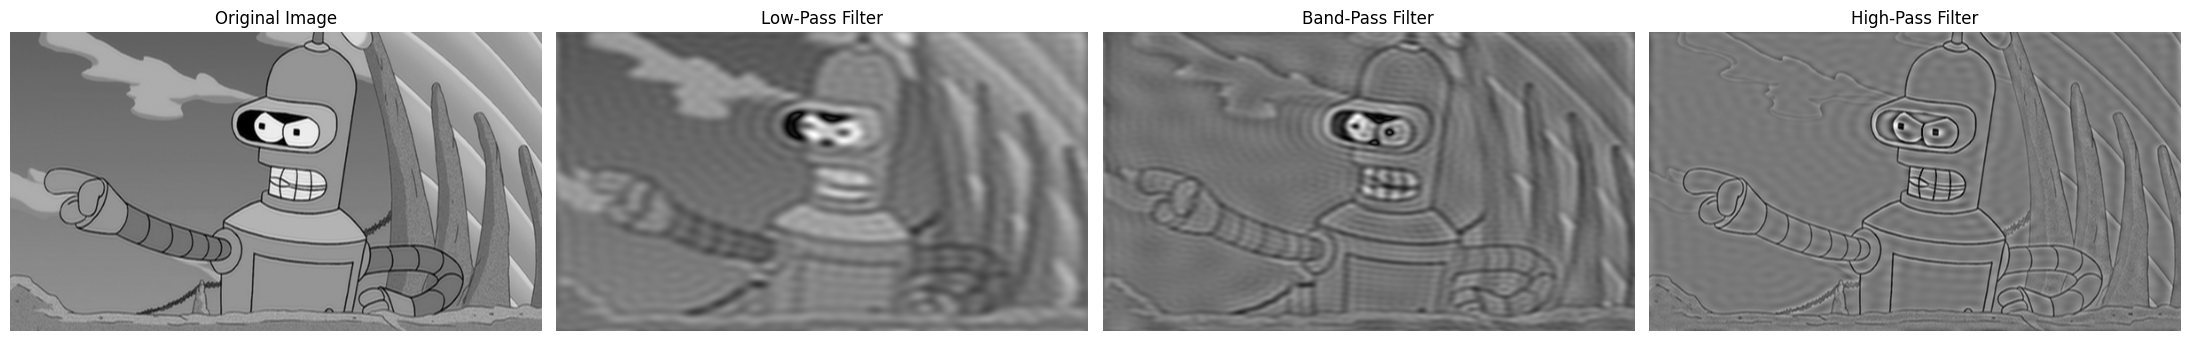

In [12]:
img_low_pass = inverse_fft_to_image(f_shift_low)
img_band_pass = inverse_fft_to_image(f_shift_band)
img_high_pass = inverse_fft_to_image(f_shift_high)

fig, ax = plt.subplots(1, 4, figsize=(22, 5))

ax[0].imshow(bender_img_gray, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(img_low_pass, cmap='gray')
ax[1].set_title('Low-Pass Filter')
ax[1].axis('off')

ax[2].imshow(img_band_pass, cmap='gray')
ax[2].set_title('Band-Pass Filter')
ax[2].axis('off')

ax[3].imshow(img_high_pass, cmap='gray')
ax[3].set_title('High-Pass Filter')
ax[3].axis('off')

plt.tight_layout()
plt.show()

În exercițiile de la laborator am avut imaginea bender_img_gray.png și m-am folosit de ea, pe aceasta am aplicat cele trei filtre.

Pentru a aplica filtrele, am folosit funcția np.fft.fft2 pentru a obține spectrul imaginii, apoi fftshift pentru a centra componentele de joasă frecvență. Am generat măști binare de tip „filtru ideal” (cu valori de 0 și 1) sub formă de cercuri și inele pentru a izola zonele de interes din spectru.

Am păstrat frecvența 0 din centrul măștii pentru filtrele band-pass și high-pass. Fără aceasta am fi avut o imagine aproape complet neagră în care se vedeau doar contururile. Astfel am reușit să mențin nuanțele de gri originale ale imaginii, aplicând efectele de filtrare direct peste fundalul vizibil.

Am setat frecvențele de tăiere (razele) empiric. Le-am ajustat prin câteva iterări până când efectele vizuale ale filtrelor (blurarea, extragerea de texturi medii și edge detection-ul) au devenit foarte clare și optime pentru demonstrație pe această imagine.

**Explicația efectelor obținute:**

**Low-pass filter**: Prin acest filtru am păstrat doar centrul spectrului (frecvențele joase) și am eliminat detaliile fine. Rezultatul este o imagine vizibil blurată. Totodată, am observat apariția unor „valuri” (efectul de ringing) în jurul contururilor, fenomen cauzat de tăierea bruscă a frecvențelor înalte prin filtrul ideal

**Band-pass filter**: Am folosit o mască în formă de inel pentru a izola o bandă medie de frecvențe. Acest proces elimină atât detaliile foarte fine (zgomotul), cât și formele foarte mari (iluminarea globală). Efectul vizual este scoaterea în evidență a elementelor de mărime medie, precum grosimea liniilor desenului.

**High-pass filter**: Am blocat frecvențele joase și am permis doar trecerea celor înalte, care corespund zonelor cu schimbări bruște de intensitate. Rezultatul este o accentuare puternică a detaliilor fine (sharpening), contururile personajului devenind mult mai pronunțate față de imaginea originală.

**Avantajul aplicării filtrării în domeniul Fourier:**

Principalul avantaj este eficiența computațională masivă la lucrul cu filtre de dimensiuni mari. În domeniul spațial, filtrarea necesită o operație de convoluție care devine foarte costisitoare pe măsură ce fereastra de calcul $K \times K$ crește. Conform Teoremei Convoluției această operație se transformă într-o simplă înmulțire element cu element în domeniul frecvenței. Astfel deși transformarea FFT inițială are un cost, aplicarea filtrului propriu-zis este instantanee, indiferent de complexitatea sau dimensiunea măștii folosite.